# Module 3 — Loan Volume Forecast

**Business Question:** How much total loan volume will Lending Club fund in the next 3 months?

**Task Type:** Time Series Regression
- Target: Monthly total `funded_amnt` aggregated from `issue_d`

**Why this module is unique:**
We transform a transaction-level dataset into a time series,
then apply both ML models (with lag features) and a dedicated
time series model (Prophet) — demonstrating two different forecasting philosophies.

**Models compared:**
1. Linear Regression (baseline)
2. XGBoost (with lag features)
3. Facebook Prophet (time series specialist)

**Pipeline:**
```
Load processed data → Aggregate to monthly → Engineer lag features →
Train/test split → Train 3 models → Evaluate (RMSE, MAPE) → Forecast next 3 months
```

## 1. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.chdir(r'C:\Users\User\Documents\finsight-forecasting')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from prophet import Prophet

# Model saving
import joblib

print('All libraries loaded successfully!')

Importing plotly failed. Interactive plots will not work.


All libraries loaded successfully!


## 2. Load Data and Aggregate to Monthly

In [2]:
df = pd.read_csv('data/processed/loans_cleaned.csv', low_memory=False)
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')

# Aggregate funded_amnt by month
df['month_start'] = df['issue_d'].dt.to_period('M').dt.to_timestamp()

monthly = (
    df.groupby('month_start')
    .agg(
        funded_amnt   = ('funded_amnt', 'sum'),
        loan_count    = ('loan_amnt',   'count'),
        avg_int_rate  = ('int_rate',    'mean'),
        avg_loan_amnt = ('loan_amnt',   'mean'),
    )
    .reset_index()
    .sort_values('month_start')
)

# Convert funded_amnt to millions for readability
monthly['funded_amnt_m'] = monthly['funded_amnt'] / 1_000_000

print(f'Monthly time series shape: {monthly.shape}')
print(f'Date range: {monthly["month_start"].min()} → {monthly["month_start"].max()}')
monthly.head()

Monthly time series shape: (139, 6)
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00


,month_start,funded_amnt,loan_count,avg_int_rate,avg_loan_amnt,funded_amnt_m
0,2007-06-01,7500.0,1,13.750000,7500.000000,0.007500
1,2007-07-01,171700.0,30,9.254667,5723.333333,0.171700
2,2007-08-01,208475.0,33,10.294848,6317.424242,0.208475
3,2007-09-01,146025.0,18,10.083889,8112.500000,0.146025
4,2007-10-01,274225.0,47,10.806809,6782.446809,0.274225


## 3. Visualise the Time Series

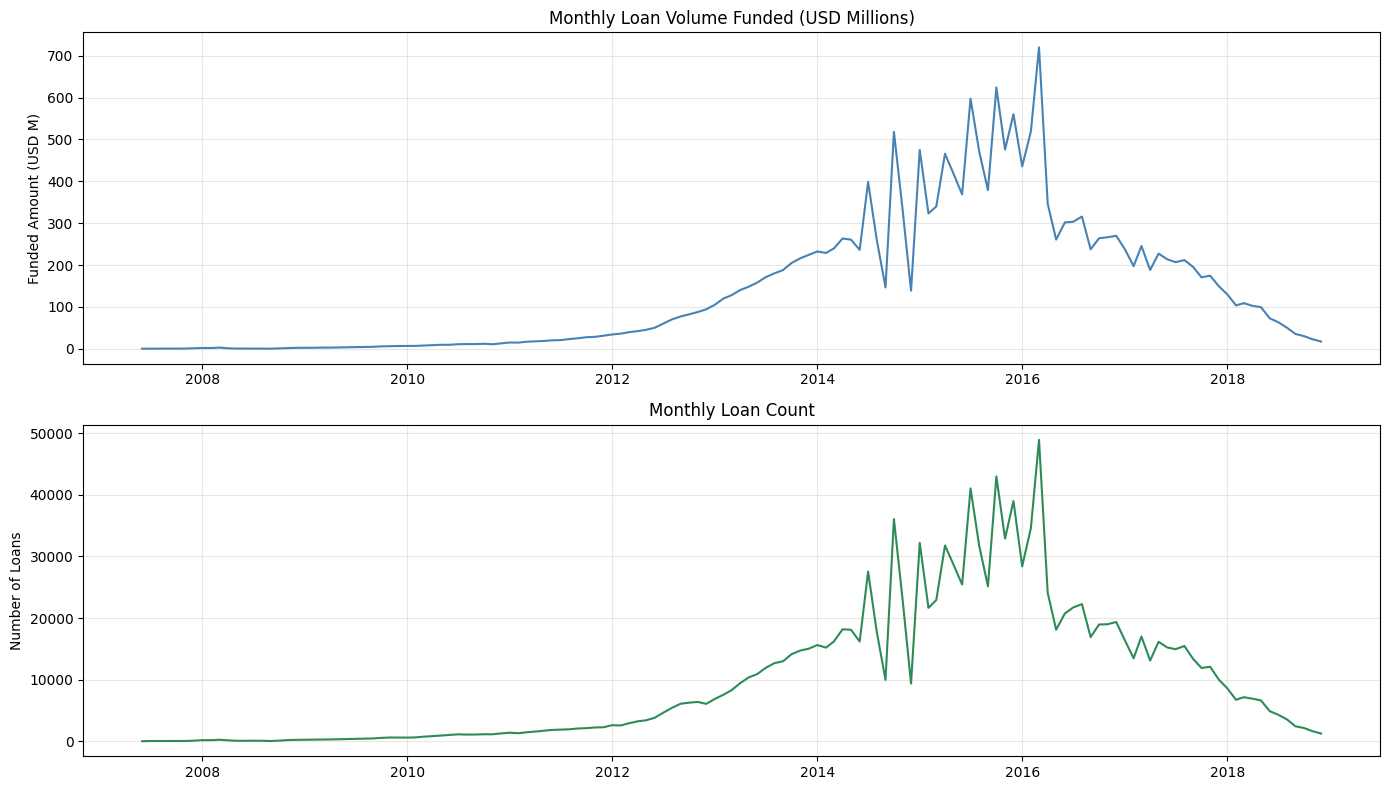

Time series plot saved to reports/


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Monthly funded amount
axes[0].plot(monthly['month_start'], monthly['funded_amnt_m'], color='steelblue', linewidth=1.5)
axes[0].set_title('Monthly Loan Volume Funded (USD Millions)')
axes[0].set_ylabel('Funded Amount (USD M)')
axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Monthly loan count
axes[1].plot(monthly['month_start'], monthly['loan_count'], color='seagreen', linewidth=1.5)
axes[1].set_title('Monthly Loan Count')
axes[1].set_ylabel('Number of Loans')
axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('reports/module3_time_series.png', dpi=150)
plt.show()
print('Time series plot saved to reports/')

## 4. Engineer Lag Features

For ML models (Linear Regression, XGBoost), we cannot feed raw dates.
Instead we create lag features — past values as predictors of future values.

In [4]:
ts = monthly.copy()

# Time features
ts['month']   = ts['month_start'].dt.month
ts['quarter'] = ts['month_start'].dt.quarter
ts['year']    = ts['month_start'].dt.year

# Lag features (past funded amounts)
for lag in [1, 2, 3, 6, 12]:
    ts[f'lag_{lag}'] = ts['funded_amnt_m'].shift(lag)

# Rolling averages
ts['rolling_3']  = ts['funded_amnt_m'].shift(1).rolling(3).mean()
ts['rolling_6']  = ts['funded_amnt_m'].shift(1).rolling(6).mean()
ts['rolling_12'] = ts['funded_amnt_m'].shift(1).rolling(12).mean()

# Month-over-month growth rate
ts['mom_growth'] = ts['funded_amnt_m'].pct_change()

# Drop rows with nulls from lag creation
ts = ts.dropna().reset_index(drop=True)

print(f'Time series with features shape: {ts.shape}')
print(f'Date range after lag: {ts["month_start"].min()} → {ts["month_start"].max()}')
ts.head(3)

Time series with features shape: (127, 18)
Date range after lag: 2008-06-01 00:00:00 → 2018-12-01 00:00:00


,month_start,funded_amnt,loan_count,avg_int_rate,avg_loan_amnt,funded_amnt_m,month,quarter,year,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,rolling_6,rolling_12,mom_growth
0,2008-06-01,377550.0,66,10.613939,5757.196970,0.377550,6,2,2008,0.378775,1.063325,2.693925,0.963625,0.007500,1.378675,1.420221,0.809156,-0.003234
1,2008-07-01,485825.0,83,10.756867,6324.397590,0.485825,7,3,2008,0.377550,0.378775,1.063325,1.742300,0.171700,0.606550,1.322542,0.839994,0.286783
2,2008-08-01,320250.0,71,11.585070,5805.633803,0.320250,8,3,2008,0.485825,0.377550,0.378775,1.679375,0.208475,0.414050,1.113129,0.866171,-0.340812


## 5. Train / Test Split

For time series we NEVER use random split.
We use the last 12 months as the test set and everything before as training.

In [28]:
FEATURES = [
    'month', 'quarter', 'year',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'rolling_3', 'rolling_6', 'rolling_12',
    'avg_int_rate', 'avg_loan_amnt', 'loan_count',
    'mom_growth'
]
TARGET = 'funded_amnt_m'

# Use 2015-01 to 2015-12 as test set
# This period has stable data without the 2016 scandal anomaly
test_mask  = (ts['month_start'] >= '2015-01-01') & (ts['month_start'] <= '2015-12-01')
train_mask = ts['month_start'] < '2015-01-01'

train_data = ts[train_mask]
test_data  = ts[test_mask]

X_train = train_data[FEATURES]
y_train = train_data[TARGET]
X_test  = test_data[FEATURES]
y_test  = test_data[TARGET]

print(f'Training set: {X_train.shape} | {train_data["month_start"].min().date()} → {train_data["month_start"].max().date()}')
print(f'Test set:     {X_test.shape}  | {test_data["month_start"].min().date()} → {test_data["month_start"].max().date()}')

Training set: (79, 15) | 2008-06-01 → 2014-12-01
Test set:     (12, 15)  | 2015-01-01 → 2015-12-01


## 6. Train Models

In [29]:
# --- Model 1: Linear Regression ---
print('Training Linear Regression...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print('Done.')

# --- Model 2: XGBoost Regressor ---
print('Training XGBoost...')
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print('Done.')

Training Linear Regression...
Done.
Training XGBoost...
Done.


In [30]:
# --- Model 3: Facebook Prophet ---
print('Training Prophet...')

# Prophet requires columns named 'ds' and 'y'
prophet_train = train_data[['month_start', TARGET]].rename(
    columns={'month_start': 'ds', TARGET: 'y'}
)

prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
prophet.fit(prophet_train)
print('Done.')

14:24:48 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet...


14:24:48 - cmdstanpy - INFO - Chain [1] done processing


Done.


## 7. Evaluate Models

In [31]:
def evaluate_regression(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'\n{"-"*40}')
    print(f'Model: {name}')
    print(f'RMSE: {rmse:.2f} USD M')
    print(f'MAPE: {mape:.2f}%')
    return rmse, mape

# Linear Regression predictions
y_pred_lr  = lr.predict(X_test_scaled)
rmse_lr, mape_lr = evaluate_regression('Linear Regression', y_test, y_pred_lr)

# XGBoost predictions
y_pred_xgb = xgb.predict(X_test)
rmse_xgb, mape_xgb = evaluate_regression('XGBoost', y_test, y_pred_xgb)

# Prophet predictions
# periods must cover the entire test set length
prophet_future   = prophet.make_future_dataframe(periods=12, freq='MS')
prophet_forecast = prophet.predict(prophet_future)

# Merge on date
test_dates_df = pd.DataFrame({
    'ds': pd.to_datetime(test_data['month_start'].values)
})
prophet_test = test_dates_df.merge(
    prophet_forecast[['ds', 'yhat']], on='ds', how='left'
)

print(f"NaN count: {prophet_test['yhat'].isna().sum()}")
y_pred_prophet = prophet_test['yhat'].values
rmse_prophet, mape_prophet = evaluate_regression('Prophet', y_test, y_pred_prophet)


----------------------------------------
Model: Linear Regression
RMSE: 10.42 USD M
MAPE: 1.92%

----------------------------------------
Model: XGBoost
RMSE: 73.07 USD M
MAPE: 10.30%
NaN count: 0

----------------------------------------
Model: Prophet
RMSE: 207.29 USD M
MAPE: 29.87%


## 8. Forecast vs Actual Plot

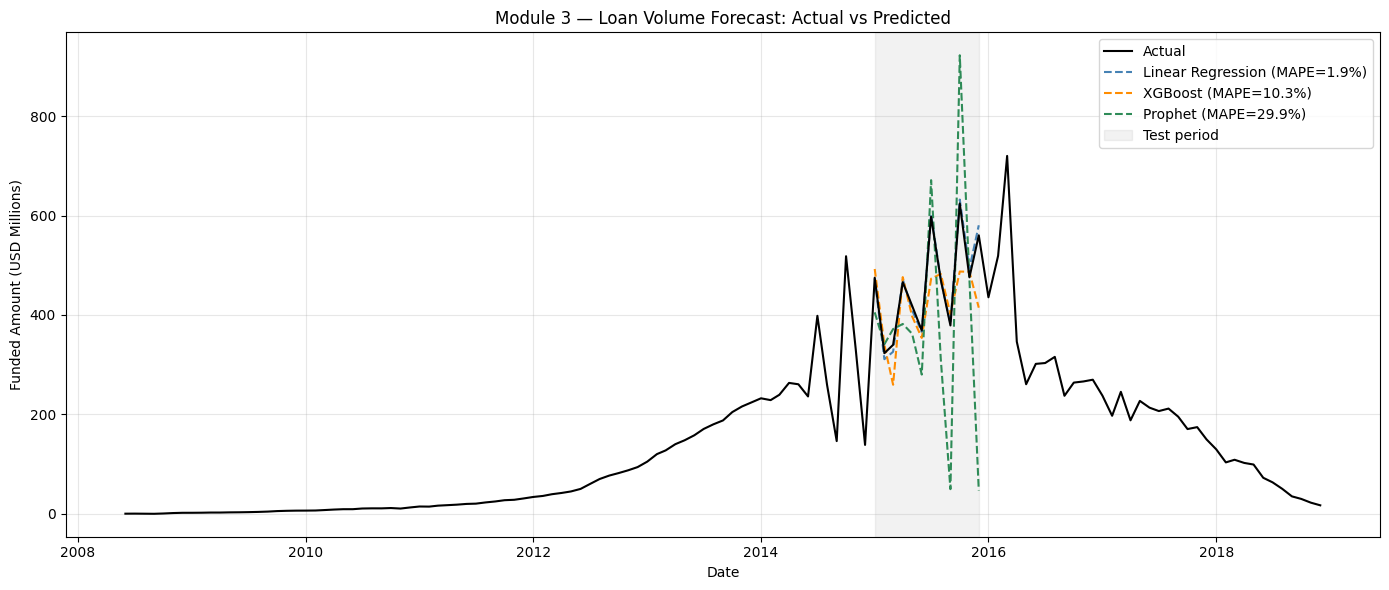

Forecast plot saved to reports/


In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

# Full actual series
ax.plot(ts['month_start'], ts[TARGET],
        color='black', linewidth=1.5, label='Actual', zorder=5)

# Test period predictions
test_dates = test_data['month_start']
ax.plot(test_dates, y_pred_lr,     '--', color='steelblue',  linewidth=1.5, label=f'Linear Regression (MAPE={mape_lr:.1f}%)')
ax.plot(test_dates, y_pred_xgb,    '--', color='darkorange',  linewidth=1.5, label=f'XGBoost (MAPE={mape_xgb:.1f}%)')
ax.plot(test_dates, y_pred_prophet,'--', color='seagreen',    linewidth=1.5, label=f'Prophet (MAPE={mape_prophet:.1f}%)')

# Shade test period
ax.axvspan(test_dates.iloc[0], test_dates.iloc[-1], alpha=0.1, color='gray', label='Test period')

ax.set_title('Module 3 — Loan Volume Forecast: Actual vs Predicted')
ax.set_ylabel('Funded Amount (USD Millions)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/module3_forecast.png', dpi=150)
plt.show()
print('Forecast plot saved to reports/')

## 9. Prophet Components Plot

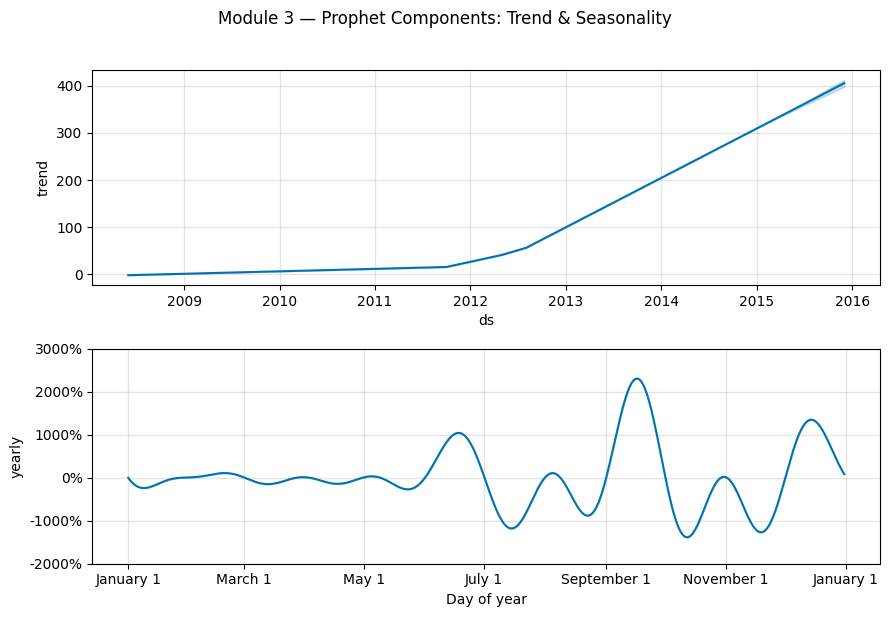

Prophet components plot saved to reports/


In [33]:
# Prophet decomposes the forecast into trend + seasonality
fig = prophet.plot_components(prophet_forecast)
plt.suptitle('Module 3 — Prophet Components: Trend & Seasonality', y=1.02)
plt.tight_layout()
plt.savefig('reports/module3_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Prophet components plot saved to reports/')

## 10. Model Comparison Summary

In [34]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost', 'Prophet'],
    'RMSE (USD M)': [round(rmse_lr, 2), round(rmse_xgb, 2), round(rmse_prophet, 2)],
    'MAPE (%)':     [round(mape_lr, 2), round(mape_xgb, 2), round(mape_prophet, 2)]
})

results = results.sort_values('MAPE (%)', ascending=True).reset_index(drop=True)
results.index += 1
print('Module 3 — Model Comparison')
print(results.to_string())

Module 3 — Model Comparison
               Model  RMSE (USD M)  MAPE (%)
1  Linear Regression         10.42      1.92
2            XGBoost         73.07     10.30
3            Prophet        207.29     29.87


## 11. Forecast Next 3 Months (Champion Model)

In [35]:
# Use Prophet to forecast next 3 months beyond the dataset
future_3m = prophet.make_future_dataframe(periods=15, freq='MS')
forecast_3m = prophet.predict(future_3m)

# Get the last 3 future months
next_3 = forecast_3m[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)
next_3.columns = ['Month', 'Forecast (USD M)', 'Lower Bound', 'Upper Bound']
next_3 = next_3.round(2)

print('3-Month Forecast (Prophet):')
print(next_3.to_string(index=False))

3-Month Forecast (Prophet):
     Month  Forecast (USD M)  Lower Bound  Upper Bound
2016-01-01            613.50       595.98       631.59
2016-02-01            451.70       435.95       467.59
2016-03-01            431.82       414.94       447.87


## 12. Save Models

In [37]:
from prophet.serialize import model_to_json

joblib.dump(lr,      'models/module3_lr.pkl')
joblib.dump(xgb,     'models/module3_xgb.pkl')
joblib.dump(scaler,  'models/module3_scaler.pkl')
joblib.dump(FEATURES,'models/module3_features.pkl')

# Save Prophet model
with open('models/module3_prophet.json', 'w') as f:
    f.write(model_to_json(prophet))

# Save monthly time series for dashboard use
monthly.to_csv('data/processed/monthly_loan_volume.csv', index=False)

print('All Module 3 models saved to models/')

All Module 3 models saved to models/
